# Logistic Regression


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from src.preprocessing import (
    base_cleaning, city_bank, approvalDate, approvalFY,
    balanceGross, createJob, disbursementDate, disbursementGross,
    LowDoc, franchise_code, urban_rural, RevLineCr,
    newExists, noemp, retainedJob, accept
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

## 2. Load Raw Data

In [2]:
df      = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test_nolabel.csv')

print('Train shape:', df.shape)
print('Test  shape:', df_test.shape)
df.head()

Train shape: (20768, 21)
Test  shape: (4070, 20)


,id,LoanNr_ChkDgt,Name,City,State,Bank,BankState,ApprovalDate,ApprovalFY,NoEmp,...,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementDate,DisbursementGross,BalanceGross,Accept
0,64afe857c28,9448323000,MIDWEST CRANKSHAFT & ENGINE,HARVEY,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,9-Aug-96,1996,28,...,0,0,1,0,N,N,31-Mar-97,"$600,000.00",$0.00,0
1,1705a7346c2,2854405007,"Iredesign, Limited",CHICAGO,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,10-Dec-07,2008,1,...,1,1,0,1,N,N,31-Dec-07,"$25,400.00",$0.00,1
2,7439801ad8a,9300423010,PHILLY'S INC.,ROCHELLE,IL,BMO HARRIS BK NATL ASSOC,IL,23-May-96,1996,6,...,0,0,1,0,N,Y,30-Sep-96,"$20,000.00",$0.00,1
3,a3f8f9d0611,4349265000,USA Laser Imaging Inc.,Loves park,IL,ALPINE BANK & TRUST CO.,IL,4-Nov-10,2011,5,...,0,5,0,1,N,N,1-Mar-11,"$75,000.00",$0.00,1
4,71e4f243b5d,2433905006,"Dan Morrell, Inc.",LISLE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,3-May-07,2007,3,...,1,3,0,1,N,N,31-May-07,"$50,000.00",$0.00,0


## 3. Preprocessing Pipeline



In [18]:
def run_preprocessing(df, is_train=True):
    df = base_cleaning.clean_base_columns(df)
    df = city_bank.get_city_bank_encoder(df)
    df = approvalDate.preprocess_approvaldate(df)
    df = approvalFY.preprocess_approvalfy(df)
    df = balanceGross.preprocess_balancegross(df)
    df = createJob.preprocess_createjob(df)
    df = disbursementDate.preprocess_disbursementdate(df)
    df = disbursementGross.preprocess_disbursementgross(df)

    # ← Opción C: genera columna binaria y elimina las columnas de texto
    df = LowDoc.preprocess_lowdoc(df, option="C")
    df = RevLineCr.preprocess_revlinecr(df, option="C")

    df = franchise_code.preprocess_franchise_code(df)
    df = urban_rural.preprocess_urban_rural(df)
    df = newExists.preprocess_newexist(df)
    df = noemp.preprocess_noemp(df)
    df = retainedJob.preprocess_retainedjob(df)

    if is_train:
        df = accept.preprocess_accept(df)

    columnas_a_eliminar = ["retainedjob_normalized", "Zone_Undefined"]
    df.drop(columns=[c for c in columnas_a_eliminar if c in df.columns], inplace=True)

    return df

## 4. Features & Target

In [20]:
TARGET   = 'Accept'
DROP_IDS = ['id']

features = [c for c in df_clean.columns if c not in [TARGET] + DROP_IDS]

# Forzar conversión a numérico de cualquier columna que quede como texto
for col in features:
    if df_clean[col].dtype == object or str(df_clean[col].dtype) == 'string':
        df_clean[col]      = pd.to_numeric(df_clean[col], errors='coerce')
        df_test_clean[col] = pd.to_numeric(df_test_clean[col], errors='coerce')
        print(f"⚠️  Convertida a numérico: {col}")

X = df_clean[features].values
y = df_clean[TARGET].values

print(f'\nFeatures ({len(features)}): {features}')
print(f'X dtype: {X.dtype} | NaN en X: {np.isnan(X.astype(float)).sum()}')
print(f'y shape: {y.shape}')

⚠️  Convertida a numérico: RevLineCr
⚠️  Convertida a numérico: LowDoc
⚠️  Convertida a numérico: LowDoc_clean
⚠️  Convertida a numérico: RevLineCr_clean

Features (39): ['City_0', 'City_1', 'City_2', 'City_3', 'City_4', 'City_5', 'City_6', 'City_7', 'City_8', 'City_9', 'City_10', 'Bank_0', 'Bank_1', 'Bank_2', 'Bank_3', 'Bank_4', 'Bank_5', 'Bank_6', 'Bank_7', 'Bank_8', 'NoEmp', 'RevLineCr', 'LowDoc', 'DisbursementGross', 'IsLocalBank', 'approvalyear_normalized', 'approvalmonth_normalized', 'createjob_normalized', 'LowDoc_clean', 'lowdoc_is_nonstandard', 'lowdoc_is_missing', 'IsFranchise', 'Zone_Rural', 'Zone_Urban', 'RevLineCr_clean', 'revlinecr_is_nonstandard', 'revlinecr_is_missing', 'is_new_business', 'newexist_missing_or_invalid']
X dtype: object | NaN en X: 78000
y shape: (20768,)


In [39]:
# Eliminar columnas de texto residuales que no aportaron información
columnas_residuales = ['RevLineCr', 'LowDoc', 'LowDoc_clean', 'RevLineCr_clean']
df_clean.drop(columns=[c for c in columnas_residuales if c in df_clean.columns], inplace=True)
df_test_clean.drop(columns=[c for c in columnas_residuales if c in df_test_clean.columns], inplace=True)

# Reconstruir features y X sin esas columnas
features = [c for c in df_clean.columns if c not in [TARGET] + DROP_IDS]
X = df_clean[features].values

print(f'Features limpias: {len(features)}')
print(f'Columnas restantes: {features}')

Features limpias: 35
Columnas restantes: ['City_0', 'City_1', 'City_2', 'City_3', 'City_4', 'City_5', 'City_6', 'City_7', 'City_8', 'City_9', 'City_10', 'Bank_0', 'Bank_1', 'Bank_2', 'Bank_3', 'Bank_4', 'Bank_5', 'Bank_6', 'Bank_7', 'Bank_8', 'NoEmp', 'DisbursementGross', 'IsLocalBank', 'approvalyear_normalized', 'approvalmonth_normalized', 'createjob_normalized', 'lowdoc_is_nonstandard', 'lowdoc_is_missing', 'IsFranchise', 'Zone_Rural', 'Zone_Urban', 'revlinecr_is_nonstandard', 'revlinecr_is_missing', 'is_new_business', 'newexist_missing_or_invalid']


## 5. Exploratory Data Analysis

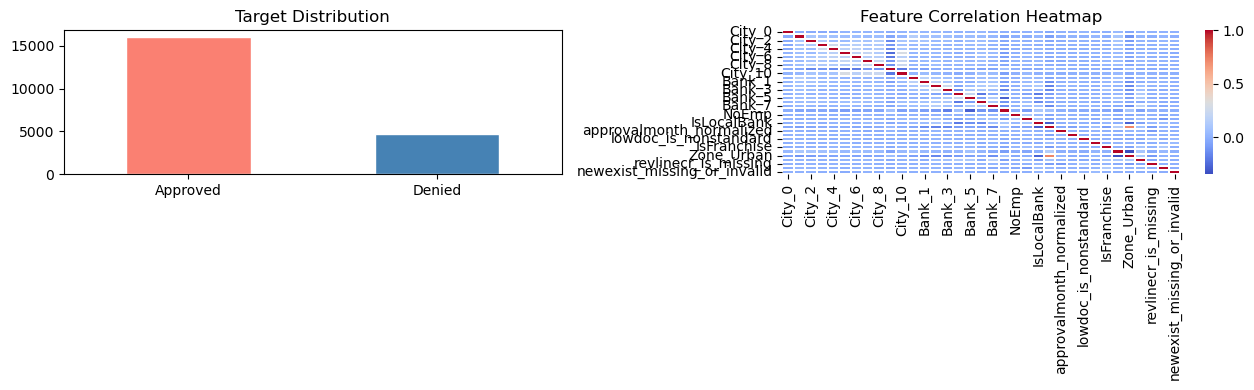

Columnas no numéricas después del preprocessing: []


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pd.Series(y).value_counts().rename({0: 'Denied', 1: 'Approved'}).plot(
    kind='bar', ax=axes[0], color=['salmon', 'steelblue'], edgecolor='white'
)
axes[0].set_title('Target Distribution')
axes[0].tick_params(axis='x', rotation=0)

# Solo columnas numéricas para el heatmap
numeric_features = df_clean[features].select_dtypes(include=[np.number]).columns.tolist()
sns.heatmap(df_clean[numeric_features].corr(), ax=axes[1], cmap='coolwarm',
            annot=False, linewidths=0.3)
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

# Muestra qué columnas NO son numéricas (para saber cuáles quedaron como texto)
non_numeric = [c for c in features if c not in numeric_features]
print("Columnas no numéricas después del preprocessing:", non_numeric)

## 6. Model — Logistic Regression Pipeline

## 7. Cross-Validation (Macro F1)

## 8. Hyperparameter Tuning (GridSearchCV)

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

param_grid = {
    'clf__C':            [0.001, 0.01, 0.05, 0.1],
    'clf__class_weight': [
        {0: 3, 1: 1},
        {0: 4, 1: 1},
        {0: 5, 1: 1},
        {0: 6, 1: 1},
    ],
    'clf__solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(
    pipeline, param_grid,
    cv=cv, scoring='f1_macro',
    n_jobs=-1, verbose=1
)
grid_search.fit(X, y)

print('Best params :', grid_search.best_params_)
print('Best CV F1  :', round(grid_search.best_score_, 4))

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params : {'clf__C': 0.001, 'clf__class_weight': {0: 3, 1: 1}, 'clf__solver': 'lbfgs'}
Best CV F1  : 0.6357


## 9. Evaluation on Full Training Set

=== Classification Report (train) ===
              precision    recall  f1-score   support

      Denied       0.40      0.63      0.49      4749
    Approved       0.87      0.72      0.79     16019

    accuracy                           0.70     20768
   macro avg       0.63      0.67      0.64     20768
weighted avg       0.76      0.70      0.72     20768

Macro F1 (train): 0.6367
Best CV F1      : 0.6357


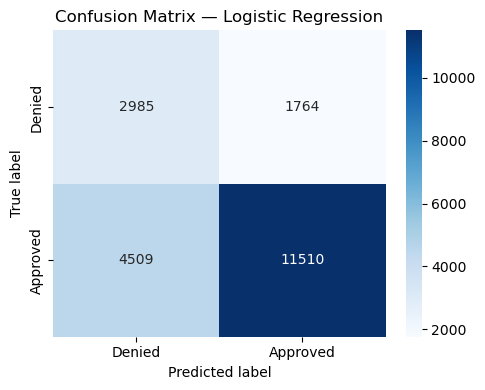

In [42]:
best_model.fit(X, y)
y_pred_train = best_model.predict(X)

print('=== Classification Report (train) ===')
print(classification_report(y, y_pred_train, target_names=['Denied', 'Approved']))
print(f'Macro F1 (train): {f1_score(y, y_pred_train, average="macro"):.4f}')
print(f'Best CV F1      : {round(grid_search.best_score_, 4)}')  # ← este es el real

cm = confusion_matrix(y, y_pred_train)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Denied', 'Approved'],
            yticklabels=['Denied', 'Approved'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

## 10. Coefficient Analysis

Número de features : 35
Número de coeficientes: 35


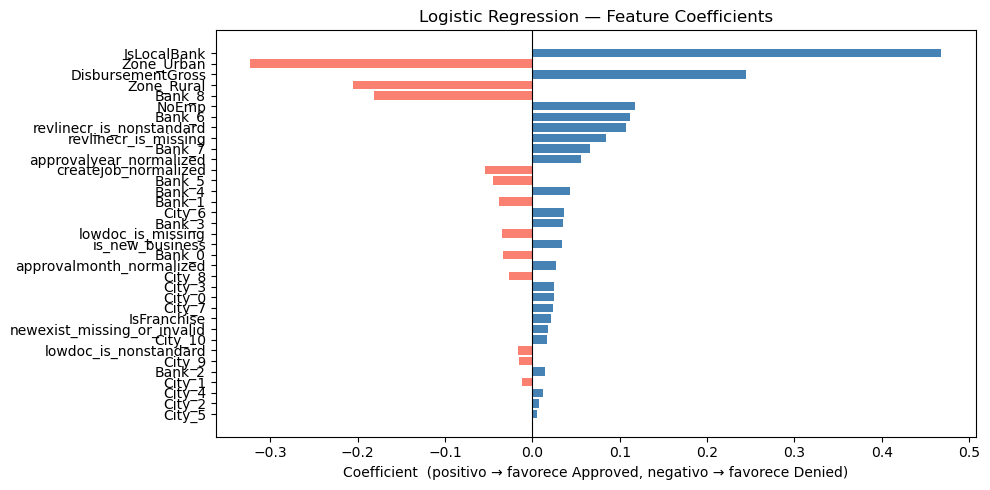

                    Feature  Coefficient
                IsLocalBank     0.468177
                 Zone_Urban    -0.322961
          DisbursementGross     0.244215
                 Zone_Rural    -0.205527
                     Bank_8    -0.181151
                      NoEmp     0.116943
                     Bank_6     0.111580
   revlinecr_is_nonstandard     0.107063
       revlinecr_is_missing     0.084029
                     Bank_7     0.066035
    approvalyear_normalized     0.055219
       createjob_normalized    -0.054756
                     Bank_5    -0.044942
                     Bank_4     0.042787
                     Bank_1    -0.038631
                     City_6     0.036392
                     Bank_3     0.034717
          lowdoc_is_missing    -0.034386
            is_new_business     0.033573
                     Bank_0    -0.033465
   approvalmonth_normalized     0.027514
                     City_8    -0.027147
                     City_3     0.025054
                

In [43]:
coef = best_model.named_steps['clf'].coef_[0]

print(f'Número de features : {len(features)}')
print(f'Número de coeficientes: {len(coef)}')

# Usar solo los primeros N features si hay diferencia de tamaño
n = min(len(features), len(coef))
feature_names = features[:n]

coef_df = (
    pd.DataFrame({'Feature': feature_names, 'Coefficient': coef[:n]})
      .assign(abs_coef=lambda d: d['Coefficient'].abs())
      .sort_values('abs_coef', ascending=False)
      .drop(columns='abs_coef')
      .reset_index(drop=True)
)

colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['Coefficient']]
plt.figure(figsize=(10, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Feature Coefficients')
plt.xlabel('Coefficient  (positivo → favorece Approved, negativo → favorece Denied)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

In [50]:
sub = pd.read_csv('submission_logistic_regression.csv')

print("=== Verificación del submission ===")
print(f"Columnas     : {list(sub.columns)}")          # debe ser ['id', 'Accept']
print(f"Filas        : {len(sub)}")                   # debe coincidir con test_nolabel
print(f"Valores únicos en Accept: {sub['Accept'].unique()}")  # solo 0 y 1
print(f"NaN en Accept: {sub['Accept'].isna().sum()}")  # debe ser 0
print(f"Tipo de Accept: {sub['Accept'].dtype}")        # debe ser int64
print()
print("Primeras filas:")
print(sub.head(10))
print()
print("Últimas filas:")
print(sub.tail(5))

=== Verificación del submission ===
Columnas     : ['id', 'Accept']
Filas        : 4070
Valores únicos en Accept: [0 1]
NaN en Accept: 0
Tipo de Accept: int64

Primeras filas:
            id  Accept
0  bae908d5352       0
1  9260b4c0f25       1
2  2c4e5bbee21       0
3  feb453f1ab5       0
4  aa32073d39f       1
5  e0617187aef       1
6  6658b8e9351       0
7  209b0ee63ae       1
8  07d086ea0b5       0
9  d93d2ff24b1       1

Últimas filas:
               id  Accept
4065  c2f5a6ccd2c       1
4066  6d254331a3c       1
4067  a8cbe303468       0
4068  953c2f91678       0
4069  e5e1ae42734       1


## 11. Predict on Test Set & Generate Submission

In [49]:
# Recuperar los ids originales del test
ids_test = pd.read_csv('data/test_nolabel.csv')['id'].reset_index(drop=True)

# Alinear columnas del test con las del train
for col in features:
    if col not in df_test_clean.columns:
        df_test_clean[col] = 0
        print(f"⚠️  Columna añadida al test con 0: {col}")

# Predecir
X_test = df_test_clean[features].values
predictions = best_model.predict(X_test)

# Construir submission desde cero con los ids originales
submission = pd.DataFrame({
    'id': ids_test,
    'Accept': predictions.astype(int)
})

print('Prediction distribution:')
print(submission['Accept'].value_counts().rename({0: 'Denied', 1: 'Approved'}))
print(f'\nFilas en submission : {len(submission)}')
print(f'Filas en test       : {len(ids_test)}')

submission.to_csv('submission_logistic_regression.csv', index=False)

print('\n✅ submission_logistic_regression.csv saved')
submission.head(10)

Prediction distribution:
Accept
Approved    2581
Denied      1489
Name: count, dtype: int64

Filas en submission : 4070
Filas en test       : 4070

✅ submission_logistic_regression.csv saved


,id,Accept
0,bae908d5352,0
1,9260b4c0f25,1
2,2c4e5bbee21,0
3,feb453f1ab5,0
4,aa32073d39f,1
5,e0617187aef,1
6,6658b8e9351,0
7,209b0ee63ae,1
8,07d086ea0b5,0
9,d93d2ff24b1,1
